In [ ]:
from api import Benchmark

bench_dir = "data/bench_full.json"
bench = Benchmark(bench_dir, cache=False)

==> Loading data...
==> No cached data found or cache set to False.
==> Reading json data...
==> Done.


In [2]:
queriable_tags = bench.get_queriable_tags()
print(queriable_tags)

['time', 'epoch', 'Train/loss', 'Train/train_accuracy', 'Train/val_accuracy', 'Train/train_cross_entropy', 'Train/val_cross_entropy', 'Train/train_balanced_accuracy', 'Train/val_balanced_accuracy', 'Train/test_result', 'Train/test_cross_entropy', 'Train/test_balanced_accuracy', 'Train/lr', 'model_parameters', 'final_train_cross_entropy', 'final_train_accuracy', 'final_train_balanced_accuracy', 'final_val_cross_entropy', 'final_val_accuracy', 'final_val_balanced_accuracy', 'final_test_cross_entropy', 'final_test_accuracy', 'final_test_balanced_accuracy', 'OpenML_task_id', 'test_split', 'budget', 'seed', 'instances', 'classes', 'features', 'batch_size', 'imputation_strategy', 'learning_rate_scheduler', 'loss', 'network', 'max_dropout', 'normalization_strategy', 'optimizer', 'cosine_annealing_T_max', 'cosine_annealing_eta_min', 'activation', 'max_units', 'mlp_shape', 'num_layers', 'learning_rate', 'momentum', 'weight_decay', 'config']


In [24]:
dataset_names = bench.get_dataset_names()
openml_task_ids = bench.get_openml_task_ids()
num_configs = bench.get_number_of_configs("airlines")

configs = 0
for dataset_name in dataset_names:
    configs += bench.get_number_of_configs(dataset_name)

print(dataset_names)
print(openml_task_ids)
print(num_configs)
print(f"Total amount of configs: {configs}")

['APSFailure', 'Amazon_employee_access', 'Australian', 'Fashion-MNIST', 'KDDCup09_appetency', 'MiniBooNE', 'adult', 'airlines', 'albert', 'bank-marketing', 'blood-transfusion-service-center', 'car', 'christine', 'cnae-9', 'connect-4', 'covertype', 'credit-g', 'dionis', 'fabert', 'helena', 'higgs', 'jannis', 'jasmine', 'jungle_chess_2pcs_raw_endgame_complete', 'kc1', 'kr-vs-kp', 'mfeat-factors', 'nomao', 'numerai28.6', 'phoneme', 'segment', 'shuttle', 'sylvine', 'vehicle', 'volkert']
[168868, 34539, 167104, 189908, 3945, 168335, 126025, 189354, 189866, 126029, 167184, 189905, 168908, 167185, 167201, 7593, 167161, 189873, 168910, 168329, 167200, 168330, 189862, 189909, 167181, 167149, 167152, 126026, 167083, 167190, 189906, 146212, 189865, 167168, 168331]
2000
Total amount of configs: 69999


In [9]:
bench.query(dataset_name="credit-g", tag="Train/loss", config_id=25, epochs="12")

[0.7330851554870605,
 0.7352434396743774,
 0.7236366868019104,
 0.6988694667816162,
 0.7095829844474792,
 0.6968463063240051,
 0.7014154195785522,
 0.682728111743927,
 0.682837963104248,
 0.6777290105819702,
 0.6872393488883972,
 0.6857050061225891,
 0.6768847107887268,
 0.6845045685768127]

In [15]:
bench.query(dataset_name="credit-g", tag="Train/loss", config_id=25, epochs="6", run_nr="2")

[0.7157478928565979,
 0.7112157940864563,
 0.695302426815033,
 0.7117289900779724,
 0.7000991106033325,
 0.6960347294807434,
 0.7000628113746643,
 0.7032541632652283]

In [18]:
len(bench.query(dataset_name="credit-g", tag="Train/loss", config_id=25, epochs="50", run_nr="2"))

52

In [9]:
entry = bench.data["credit-g"]["0"]
print(entry.keys())

dict_keys(['25', '50', '6', '12'])


In [8]:
# Get an example for a loss log
example_loss = bench.query(dataset_name="higgs", tag="Train/loss", config_id=0)

# Get the log of the accuracy for the run with the best peak accuracy
example_best_acc = bench.query_best(dataset_name="higgs", tag="Train/val_accuracy", criterion="Train/val_accuracy")

# Get the configuration of the best performing configuration
example_best_config = bench.query_best(dataset_name="higgs", tag="config", criterion="Train/val_accuracy")

print("Example loss log:\n", example_loss)
print("Best validation accuracy log:\n", example_best_acc)
print("Best config with regard to validation accuracy:\n", example_best_config)

Example loss log:
 [0.6998428106307983, 0.6986261606216431, 0.6964662075042725, 0.6950410604476929, 0.6947504281997681, 0.6941385269165039, 0.6936721205711365, 0.6935209035873413, 0.693234384059906, 0.6929869055747986, 0.6926015019416809, 0.6925884485244751, 0.6926867961883545, 0.6924664974212646, 0.6924716830253601, 0.6924899220466614, 0.6924484372138977, 0.6927175521850586, 0.6922895312309265, 0.6923630237579346, 0.6923500895500183, 0.6923447251319885, 0.6922466158866882, 0.6925037503242493, 0.6924065947532654, 0.6924857497215271, 0.6921402215957642]
Best validation accuracy log:
 [53.422508239746094, 65.46125793457031, 67.0295181274414, 67.90129089355469, 68.6854248046875, 69.08671569824219, 68.63007354736328, 68.1503677368164, 69.10516357421875, 68.90221405029297, 68.78228759765625, 69.32656860351562, 69.25737762451172, 69.58026123046875, 69.612548828125, 69.53874206542969, 70.1337661743164, 70.41973876953125, 70.09686279296875, 69.98616027832031, 70.5996322631836, 71.120849609375,

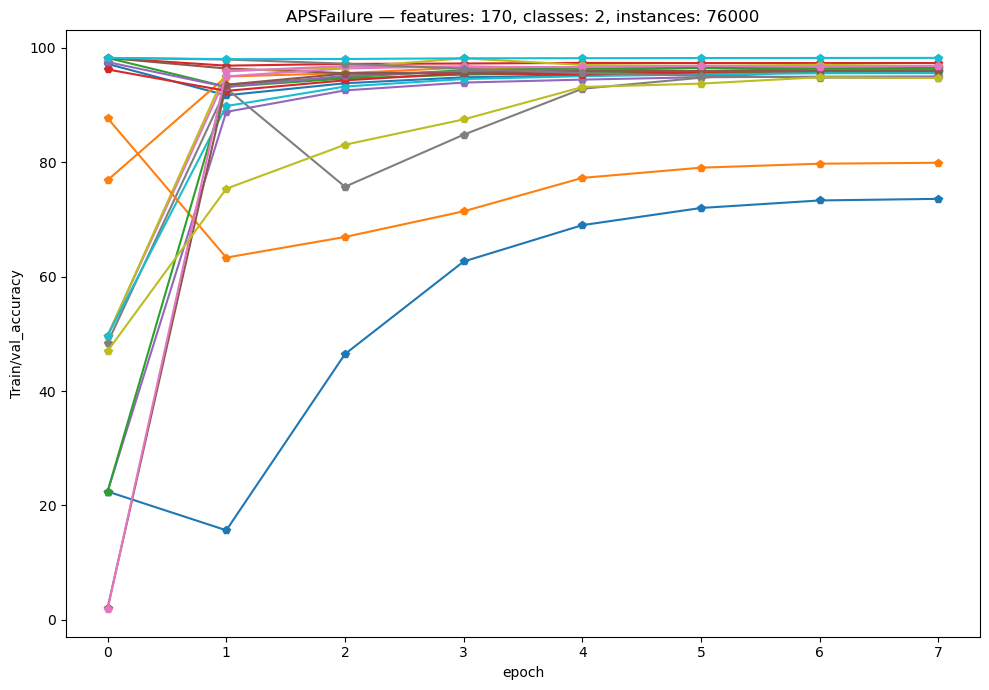

In [23]:
bench.plot_by_name(
   dataset_names=["APSFailure", ], # Fashion-MNIST"
   x_col="epoch",
   y_col="Train/val_accuracy",
   n_configs=20,
   xscale='linear',
   yscale='linear',
   epochs="6",
   show_best=False,
   criterion="Train/train_accuracy"
)